In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(7043, 21)

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [10]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [11]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isnull().sum()

np.int64(11)

In [12]:
mask = pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()

df.loc[mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [13]:
df.loc[mask, "TotalCharges"].unique()

<ArrowStringArray>
[' ']
Length: 1, dtype: str

In [14]:
df["customerID"].nunique()

7043

In [15]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [17]:
df.describe(include="object")

/var/folders/_s/l9md4_2x5rj1z5hmcz54bvnr0000gn/T/ipykernel_1140/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [18]:
categorical_cols = df.select_dtypes(include="str").columns.drop(["customerID", "TotalCharges"])

for col in categorical_cols:
    print(col, ":", df[col].unique())

gender : <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner : <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines : <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService : <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup : <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length

In [19]:
for col in df.select_dtypes(include="str").columns:
    count = (df[col] != df[col].str.strip()).sum()
    if count > 0:
        print(col, count)

TotalCharges 11


In [20]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")

In [21]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isnull().sum()

np.int64(0)

In [22]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [23]:
df["TotalCharges"].dtype

dtype('float64')

In [24]:
df = df.drop(columns="customerID")

In [25]:
df.shape

(7043, 20)

In [26]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

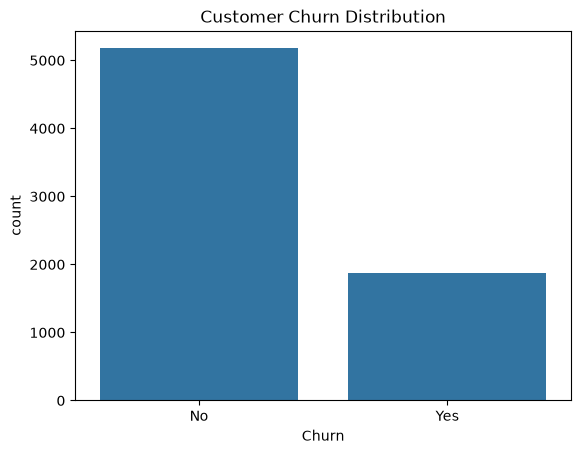

In [27]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

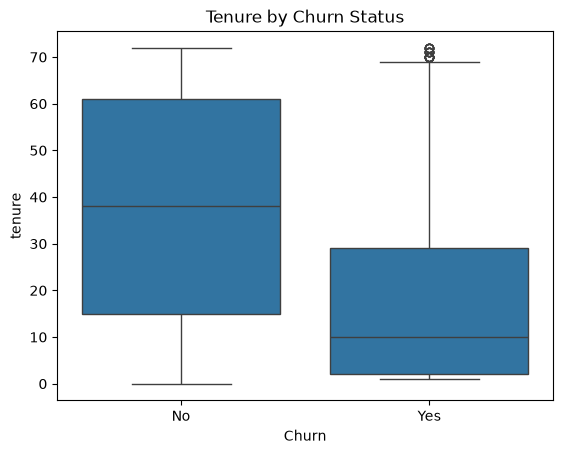

In [28]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn Status")
plt.show()

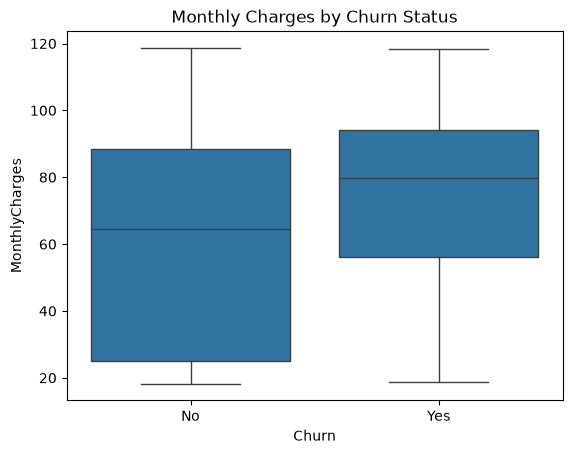

In [29]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.show()

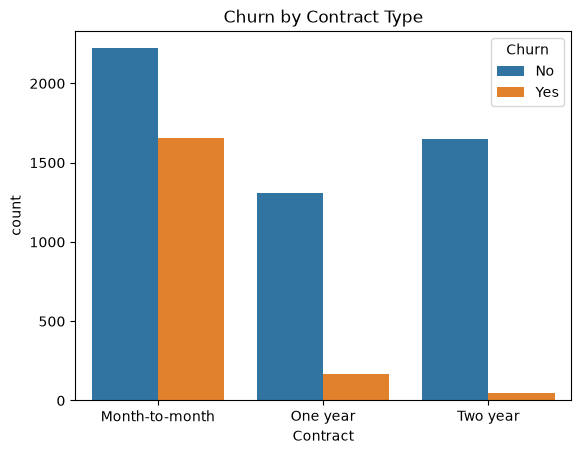

In [30]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

In [31]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


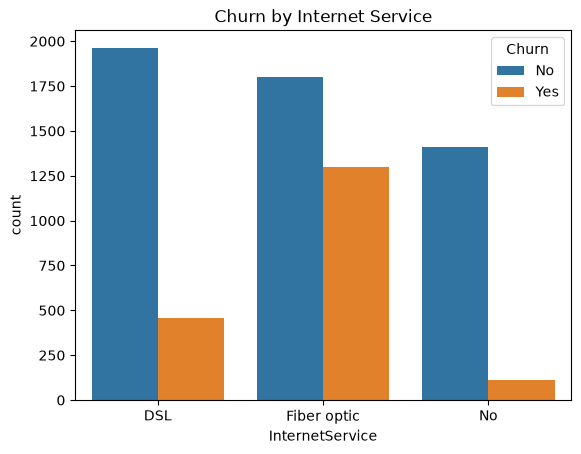

In [32]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

In [33]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


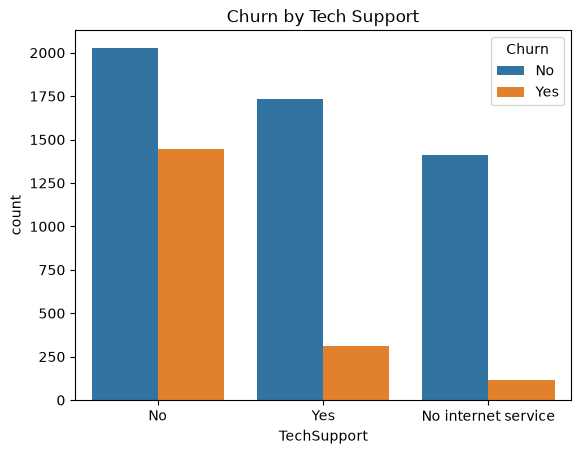

In [34]:
sns.countplot(data=df, x="TechSupport", hue="Churn")
plt.title("Churn by Tech Support")
plt.show()

In [35]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


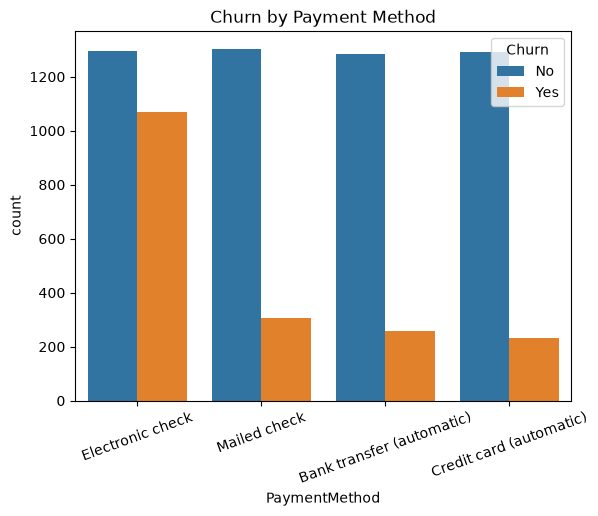

In [36]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xticks(rotation=20)
plt.show()

In [37]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


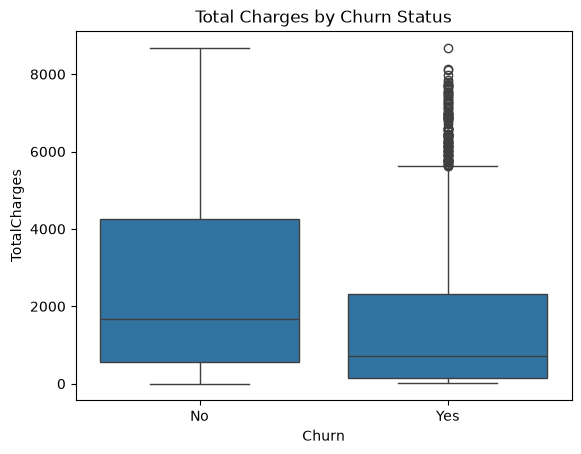

In [38]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges by Churn Status")
plt.show()

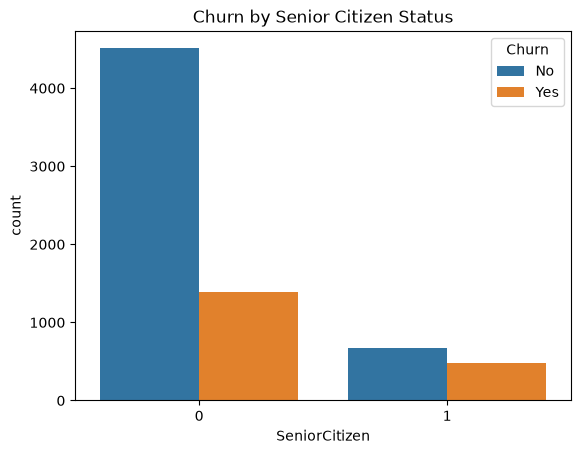

In [39]:
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Churn by Senior Citizen Status")
plt.show()

In [40]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


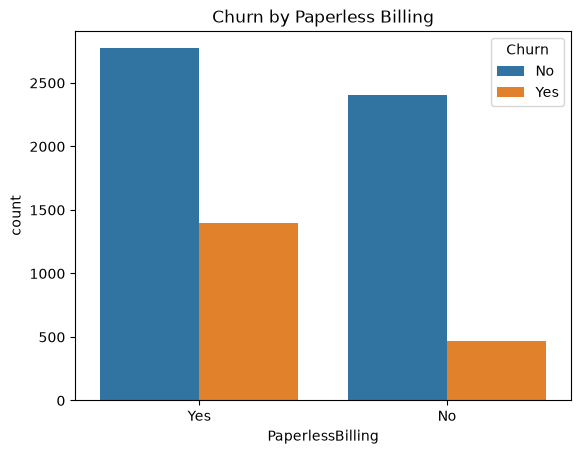

In [41]:
sns.countplot(data=df, x="PaperlessBilling", hue="Churn")
plt.title("Churn by Paperless Billing")
plt.show()

In [42]:
pd.crosstab(df["PaperlessBilling"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


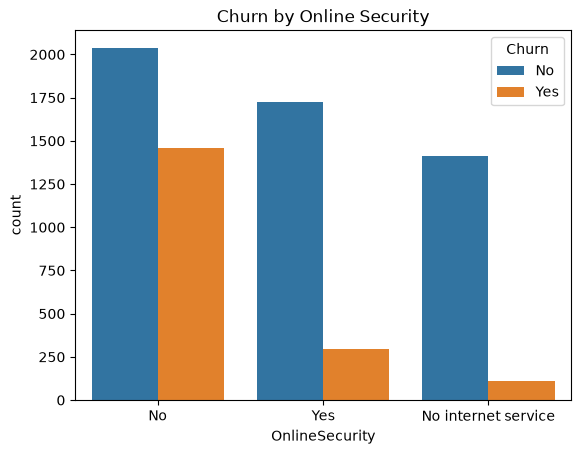

In [43]:
sns.countplot(data=df, x="OnlineSecurity", hue="Churn")
plt.title("Churn by Online Security")
plt.show()

In [44]:
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index") * 100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [45]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


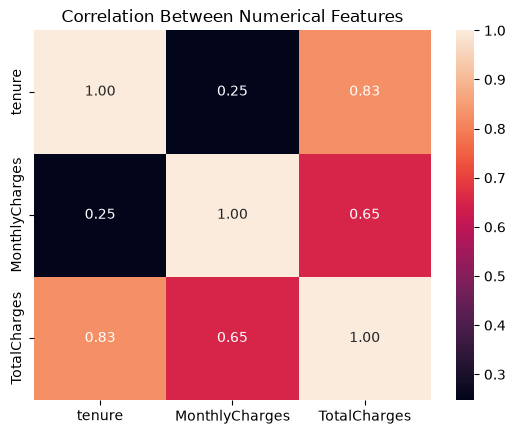

In [46]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Between Numerical Features")
plt.show()

In [47]:
X = df.drop(columns="Churn")
y = df["Churn"]

In [48]:
X.shape, y.shape

((7043, 19), (7043,))

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

In [52]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
Churn
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64

Test distribution:
Churn
No     73.456352
Yes    26.543648
Name: proportion, dtype: float64


In [53]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')

In [54]:
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [55]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [57]:
from sklearn.pipeline import Pipeline

In [58]:
from sklearn.linear_model import LogisticRegression

In [59]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

In [60]:
from sklearn.model_selection import StratifiedKFold

In [61]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [62]:
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import cross_val_score

In [63]:
f1_scorer = make_scorer(f1_score, pos_label="Yes")

In [64]:
baseline_scores = cross_val_score(
    baseline_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=f1_scorer
)

In [65]:
baseline_scores

array([0.58500914, 0.54945055, 0.58888889, 0.64248705, 0.59622642])

In [66]:
baseline_scores.mean()

np.float64(0.5924124081667455)

In [67]:
baseline_scores.std()

np.float64(0.029782414028798505)

In [68]:
from sklearn.model_selection import cross_validate

In [69]:
cv_results = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=f1_scorer,
    return_train_score=True
)

In [70]:
cv_results["train_score"], cv_results["test_score"]

(array([0.60437557, 0.61426624, 0.60759494, 0.59088817, 0.59663483]),
 array([0.58500914, 0.54945055, 0.58888889, 0.64248705, 0.59622642]))

In [71]:
cv_results["train_score"].mean(), cv_results["test_score"].mean()

(np.float64(0.6027519512219262), np.float64(0.5924124081667455))

In [72]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [73]:
from sklearn.tree import DecisionTreeClassifier

In [74]:
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

In [75]:
tree_cv_results = cross_validate(
    tree_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=f1_scorer,
    return_train_score=True
)

In [76]:
tree_cv_results["train_score"], tree_cv_results["test_score"]

(array([0.99664711, 0.99748533, 0.99664711, 0.99706745, 0.99622325]),
 array([0.48739496, 0.49087894, 0.5258216 , 0.4921466 , 0.48424544]))

In [77]:
tree_cv_results["train_score"].mean(), tree_cv_results["test_score"].mean()

(np.float64(0.9968140488093328), np.float64(0.4960975058390833))

In [78]:
from sklearn.ensemble import RandomForestClassifier

In [79]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

In [80]:
rf_cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=f1_scorer,
    return_train_score=True
)

In [81]:
rf_cv_results["train_score"], rf_cv_results["test_score"]

(array([0.99665552, 0.99748744, 0.99665552, 0.9970699 , 0.99622958]),
 array([0.52962963, 0.50769231, 0.57826888, 0.52851711, 0.55776892]))

In [82]:
rf_cv_results["train_score"].mean(), rf_cv_results["test_score"].mean()

(np.float64(0.9968195909150748), np.float64(0.5403753697004607))

In [83]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]

In [84]:
depth_results = []

for depth in depths:
    pipeline = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", DecisionTreeClassifier(max_depth=depth, random_state=42))
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring=f1_scorer,
        return_train_score=True
    )

    depth_results.append([
        depth,
        scores["train_score"].mean(),
        scores["test_score"].mean()
    ])

In [85]:
depth_results

[[1, np.float64(0.0), np.float64(0.0)],
 [2, np.float64(0.5871425788748883), np.float64(0.5872866321750498)],
 [3, np.float64(0.48558334566562084), np.float64(0.47795551728917046)],
 [4, np.float64(0.5516207689760665), np.float64(0.5385271015323504)],
 [5, np.float64(0.5971509829883267), np.float64(0.5648998855003258)],
 [6, np.float64(0.6183157881658836), np.float64(0.5636960837549705)],
 [8, np.float64(0.6967796977808595), np.float64(0.5646890884134914)],
 [10, np.float64(0.7831791101854801), np.float64(0.5260400579018223)],
 [None, np.float64(0.9968140488093328), np.float64(0.4960975058390833)]]

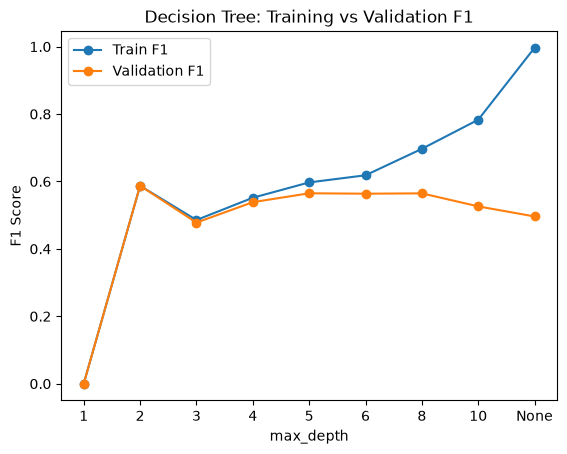

In [86]:
depth_labels = [str(d) for d in depths]

train_scores = [row[1] for row in depth_results]
val_scores = [row[2] for row in depth_results]

plt.plot(depth_labels, train_scores, marker="o", label="Train F1")
plt.plot(depth_labels, val_scores, marker="o", label="Validation F1")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.title("Decision Tree: Training vs Validation F1")
plt.legend()
plt.show()

In [87]:
from sklearn.model_selection import GridSearchCV

In [88]:
tree_param_grid = {
    "model__max_depth": [2, 4, 6, 8],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10]
}

In [89]:
tree_grid_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    cv=skf,
    scoring=f1_scorer,
    n_jobs=-1
)

In [90]:
tree_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [2, 4, ...], 'model__min_samples_leaf': [1, 5, ...], 'model__min_samples_split': [2, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...pos_label=Yes)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 

In [91]:
tree_grid_search.best_params_, tree_grid_search.best_score_

({'model__max_depth': 2,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 2},
 np.float64(0.5872866321750498))

In [92]:
from sklearn.model_selection import RandomizedSearchCV

In [93]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10]
}

In [94]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=skf,
    scoring=f1_scorer,
    random_state=42,
    n_jobs=-1
)

In [95]:
rf_random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(f...pos_label=Yes)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits 

In [96]:
rf_random_search.best_params_, rf_random_search.best_score_

({'model__n_estimators': 100,
  'model__min_samples_split': 20,
  'model__min_samples_leaf': 5,
  'model__max_depth': 8},
 np.float64(0.5834435947539368))

In [101]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            solver="saga",
            max_iter=2000,
            random_state=42
        ))
    ]
)

In [102]:
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0, 1]
}

In [103]:
lr_grid_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=lr_param_grid,
    cv=skf,
    scoring=f1_scorer,
    n_jobs=-1
)

In [104]:
lr_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__l1_ratio': [0, 1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...pos_label=Yes)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: 

In [105]:
lr_grid_search.best_params_, lr_grid_search.best_score_

({'model__C': 10, 'model__l1_ratio': 1}, np.float64(0.5975404089588198))

In [106]:
from sklearn.ensemble import GradientBoostingClassifier

In [107]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ]
)

In [108]:
gb_cv_results = cross_validate(
    gb_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=f1_scorer,
    return_train_score=True
)

In [109]:
gb_cv_results["train_score"], gb_cv_results["test_score"]

(array([0.64645522, 0.66332117, 0.64074074, 0.64491726, 0.63847584]),
 array([0.56873823, 0.54205607, 0.61121157, 0.59926471, 0.62239089]))

In [110]:
gb_cv_results["train_score"].mean(), gb_cv_results["test_score"].mean()

(np.float64(0.6467820453237982), np.float64(0.5887322950962768))

In [111]:
best_lr = lr_grid_search.best_estimator_

In [112]:
feature_names = best_lr.named_steps["preprocessor"].get_feature_names_out()

In [113]:
feature_names[:20]

array(['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges',
       'cat__gender_Female', 'cat__gender_Male', 'cat__SeniorCitizen_0',
       'cat__SeniorCitizen_1', 'cat__Partner_No', 'cat__Partner_Yes',
       'cat__Dependents_No', 'cat__Dependents_Yes',
       'cat__PhoneService_No', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_DSL',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No'], dtype=object)

In [114]:
coefficients = best_lr.named_steps["model"].coef_[0]

In [115]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

In [116]:
coef_df.sort_values("coefficient", ascending=False).head(10)

,feature,coefficient
17,cat__InternetService_Fiber optic,2.460802
36,cat__StreamingMovies_Yes,0.884287
33,cat__StreamingTV_Yes,0.883467
37,cat__Contract_Month-to-month,0.698430
15,cat__MultipleLines_Yes,0.617433
2,num__TotalCharges,0.578596
44,cat__PaymentMethod_Electronic check,0.310942
27,cat__DeviceProtection_Yes,0.288625
24,cat__OnlineBackup_Yes,0.150197
19,cat__OnlineSecurity_No,0.094290


In [117]:
coef_df.sort_values("coefficient").head(10)

,feature,coefficient
1,num__MonthlyCharges,-2.012336
0,num__tenure,-1.300387
39,cat__Contract_Two year,-0.671790
14,cat__MultipleLines_No phone service,-0.377189
11,cat__PhoneService_No,-0.377189
40,cat__PaperlessBilling_No,-0.369313
26,cat__DeviceProtection_No internet service,-0.334999
23,cat__OnlineBackup_No internet service,-0.334999
29,cat__TechSupport_No internet service,-0.334999
35,cat__StreamingMovies_No internet service,-0.334999


In [118]:
(coef_df["coefficient"] == 0).sum()

np.int64(11)

In [119]:
coef_df[coef_df["coefficient"] == 0]

,feature,coefficient
4,cat__gender_Male,0.0
13,cat__MultipleLines_No,0.0
16,cat__InternetService_DSL,0.0
21,cat__OnlineSecurity_Yes,0.0
22,cat__OnlineBackup_No,0.0
25,cat__DeviceProtection_No,0.0
30,cat__TechSupport_Yes,0.0
31,cat__StreamingTV_No,0.0
34,cat__StreamingMovies_No,0.0
38,cat__Contract_One year,0.0


In [120]:
y_pred = best_lr.predict(X_test)

In [121]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [122]:
y_proba = best_lr.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="Yes"))
print("Recall:", recall_score(y_test, y_pred, pos_label="Yes"))
print("F1:", f1_score(y_test, y_pred, pos_label="Yes"))
print("ROC-AUC:", roc_auc_score((y_test == "Yes").astype(int), y_proba))

Accuracy: 0.8048261178140526
Precision: 0.6551724137931034
Recall: 0.5588235294117647
F1: 0.6031746031746031
ROC-AUC: 0.8412617220801364


In [123]:
from sklearn.metrics import confusion_matrix

In [124]:
cm = confusion_matrix(y_test, y_pred, labels=["No", "Yes"])
cm

array([[925, 110],
       [165, 209]])

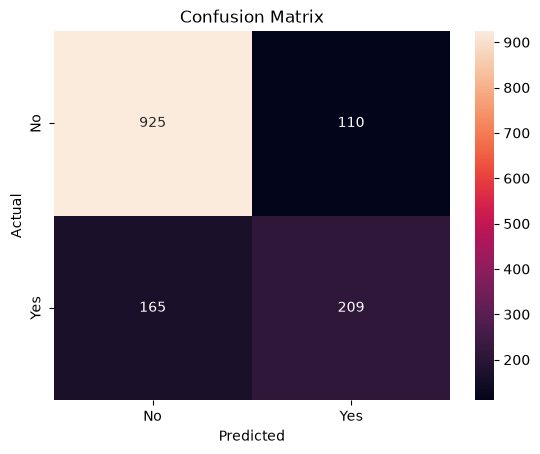

In [125]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [126]:
import joblib

In [127]:
joblib.dump(best_lr, "customer_churn_pipeline.joblib")

['customer_churn_pipeline.joblib']

In [128]:
loaded_pipeline = joblib.load("customer_churn_pipeline.joblib")

In [129]:
loaded_pipeline.predict(X_test.iloc[:5])

array(['No', 'Yes', 'No', 'No', 'No'], dtype=object)